# MrSQM vs HYDRA — Reproducibility & Statistical Analysis

In [29]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

### Step up the environment and output directory for figures

In [30]:
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [31]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

C_MRSQM   = "#E69F00"   # amber
C_HYDRA   = "#0072B2"   # blue
C_POS     = "#009E73"   # green  (our result > reported)
C_NEG     = "#D55E00"   # red    (our result < reported)
C_NEUTRAL = "#999999"   # grey

In [32]:
from mrsqm_vs_hyrda_utils import (
    load_data,
    compute_summary_stats,
    compute_average_ranks,
    run_wilcoxon_tests,
    plot_scatter_my_vs_reported,
    plot_diff_bars,
    _plot_critical_difference
)

In [33]:
df = load_data()
print(f"\nLoaded {len(df)} datasets.")

model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000
          count      mean       std       min      25%       50%       75%  \
accuracy  112.0  0.873464  0.131359  0.329712  0.80614  0.929979  0.971218   

          max  
accuracy  1.0  
              count      mean       std    min    25%    50%    75%  max
MrSQM_SFA_k5  113.0  0.853619  0.140923  

In [34]:
df

,dataset,mrsqm,hydra,mrsqm_reported,hydra_reported,mrsqm_diff,hydra_diff,my_winner,rep_winner,rank_agrees
0,ACSF1,0.930000,0.880000,0.890,0.806667,0.040000,0.073333,mrsqm,mrsqm,True
1,Adiac,0.818414,0.813299,0.811,0.815772,0.007414,-0.002473,mrsqm,hydra,False
2,ArrowHead,0.811429,0.811429,0.851,0.869714,-0.039571,-0.058285,tie,hydra,False
3,Beef,0.766667,0.833333,0.800,0.805556,-0.033333,0.027777,hydra,hydra,True
4,BeetleFly,0.950000,0.900000,0.950,0.951667,0.000000,-0.051667,mrsqm,hydra,False
...,...,...,...,...,...,...,...,...,...,...
107,Wine,0.833333,0.888889,0.889,0.951235,-0.055667,-0.062346,hydra,hydra,True
108,WordSynonyms,0.686520,0.744514,0.677,0.749948,0.009520,-0.005434,hydra,hydra,True
109,Worms,0.714286,0.740260,0.753,0.753247,-0.038714,-0.012987,hydra,hydra,True
110,WormsTwoClass,0.779221,0.766234,0.805,0.805195,-0.025779,-0.038961,mrsqm,hydra,False


In [35]:
# 1. Summary statistics
summary_df = compute_summary_stats(df)


SUMMARY STATISTICS  (accuracy, N=112)
                   Mean    Std  Median    Min    Max
Model                                               
MrSQM (ours)     0.8556 0.1395  0.9080 0.3660 1.0000
HYDRA (ours)     0.8563 0.1488  0.9036 0.3244 1.0000
MrSQM (reported) 0.8524 0.1409  0.8915 0.3720 1.0000
HYDRA (reported) 0.8735 0.1314  0.9300 0.3297 1.0000

Win counts (head-to-head per dataset):
  My results: MrSQM=44  HYDRA=52  Tie=16  (N=112)
  Reported: MrSQM=41  HYDRA=69  Tie=2  (N=112)

Ranking agreement (my vs reported winner): 71/112 = 63.4%


In [36]:
# 2. Average ranks
rank_results = compute_average_ranks(df)


AVERAGE RANK  (lower = better, N=112)
  My results        MrSQM=1.5357  HYDRA=1.4643  => winner: HYDRA
  Reported          MrSQM=1.6250  HYDRA=1.3750  => winner: HYDRA


In [37]:
# 3. Wilcoxon tests
wilcoxon_df = run_wilcoxon_tests(df)


WILCOXON SIGNED-RANK TESTS

  (A) H2H — ours
    Is HYDRA significantly better than MrSQM in our single-run experiments?
    n= 96  W=2196.50  p=0.6308  n.s.  mean_diff=+0.0007

  (B) H2H — reported
    Is HYDRA significantly better than MrSQM in the reported results?
    n=110  W=1916.00  p=0.0007  ***  mean_diff=+0.0211

  (C) Repro — MrSQM
    Do our MrSQM results significantly differ from the reported figures?
    n=103  W=2578.00  p=0.7422  n.s.  mean_diff=+0.0033

  (D) Repro — HYDRA
    Do our HYDRA results significantly differ from the reported figures?
    n=107  W=2152.00  p=0.0220  *  mean_diff=-0.0171

  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  n.s. p>=0.05


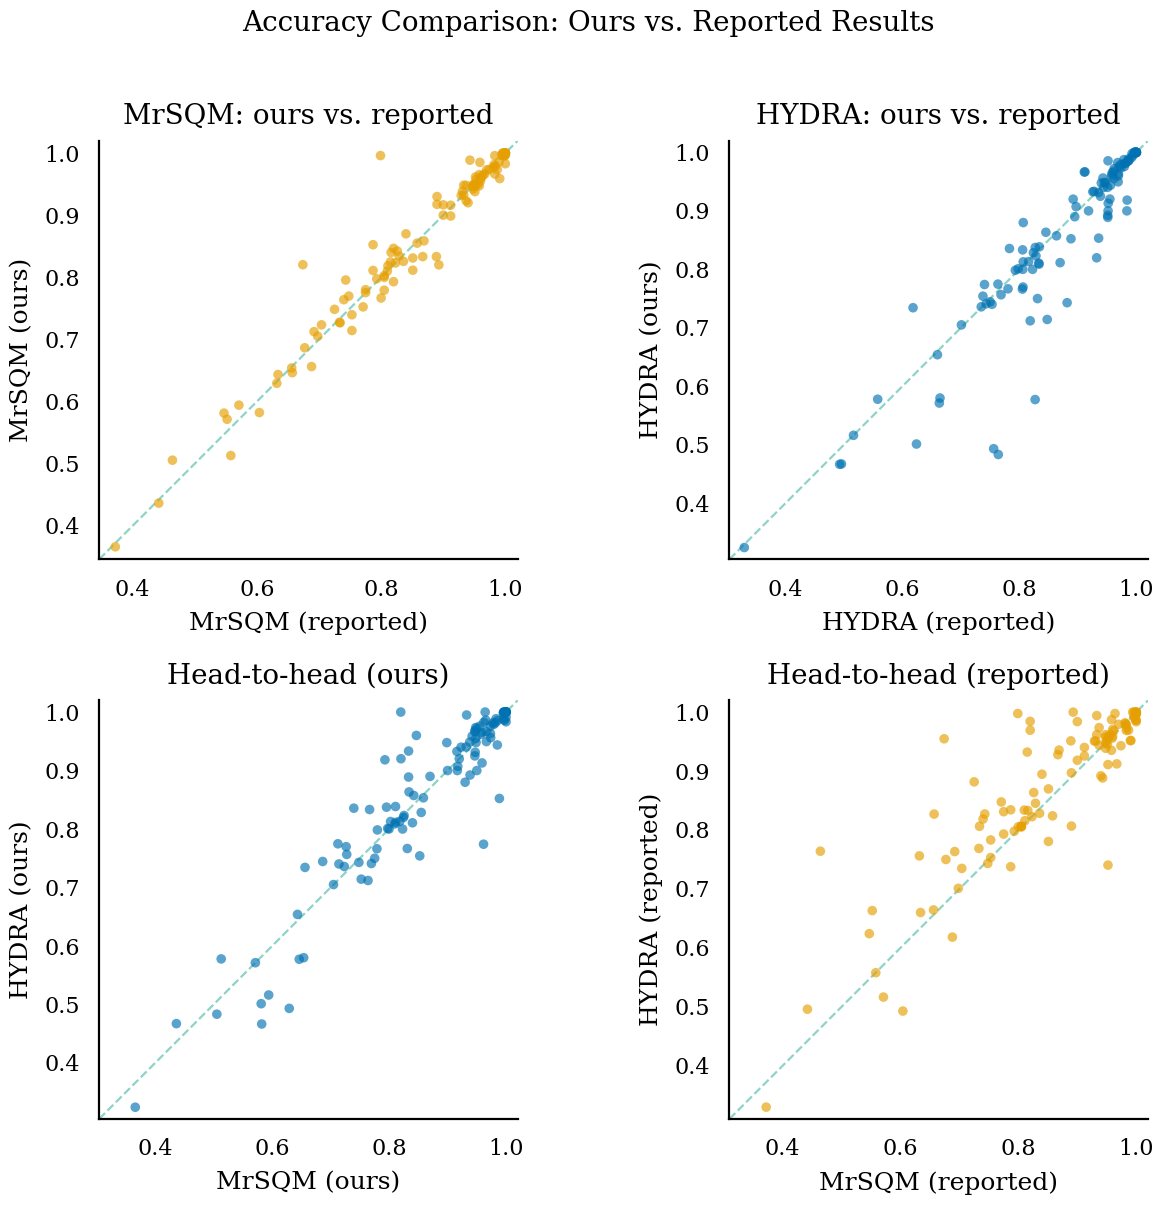


[plot_scatter_my_vs_reported] Saved -> figures/scatter_my_vs_reported.png


'figures/scatter_my_vs_reported.png'

In [38]:
plot_scatter_my_vs_reported(df)

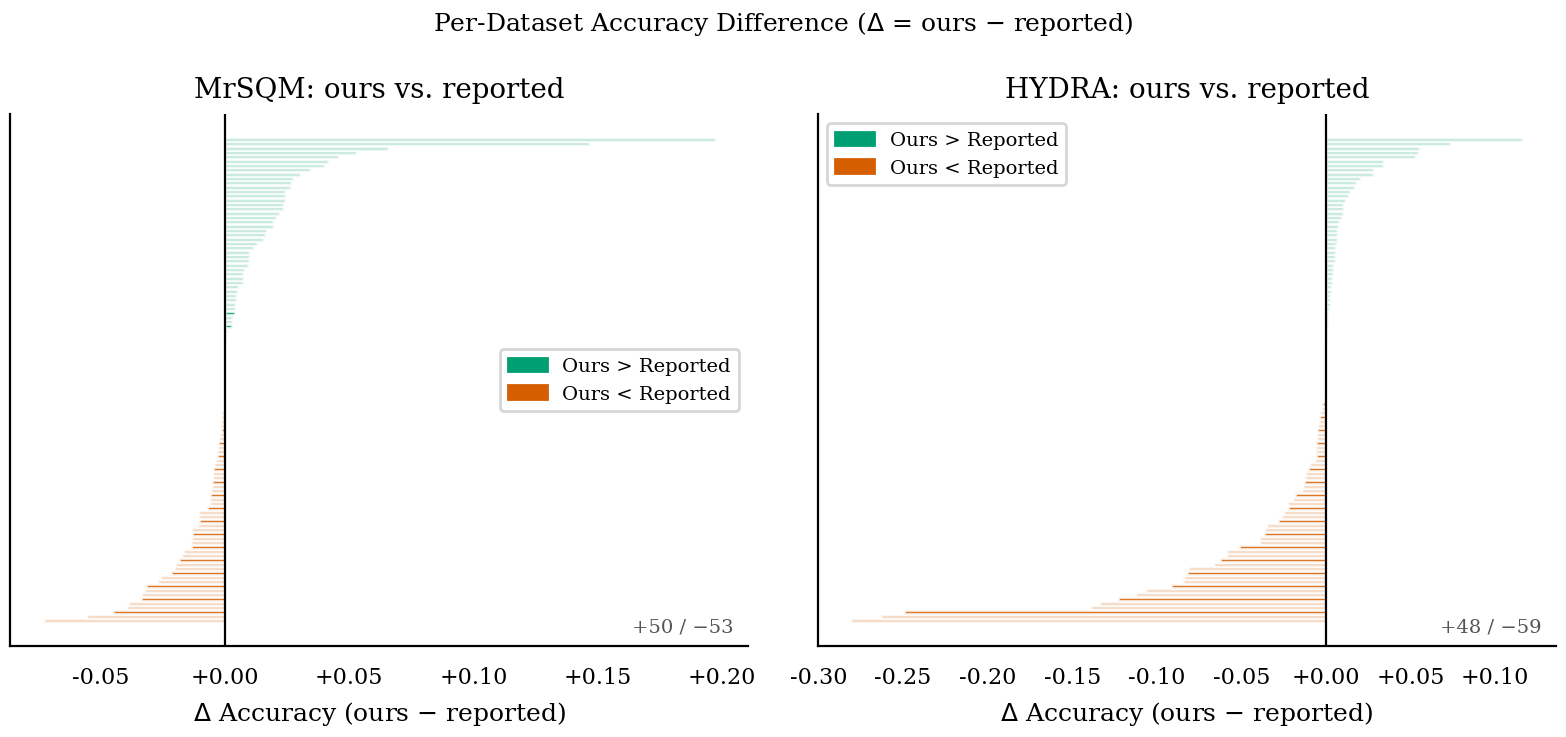

[plot_diff_bars] Saved -> figures/diff_bars.png


'figures/diff_bars.png'

In [39]:
plot_diff_bars(df)

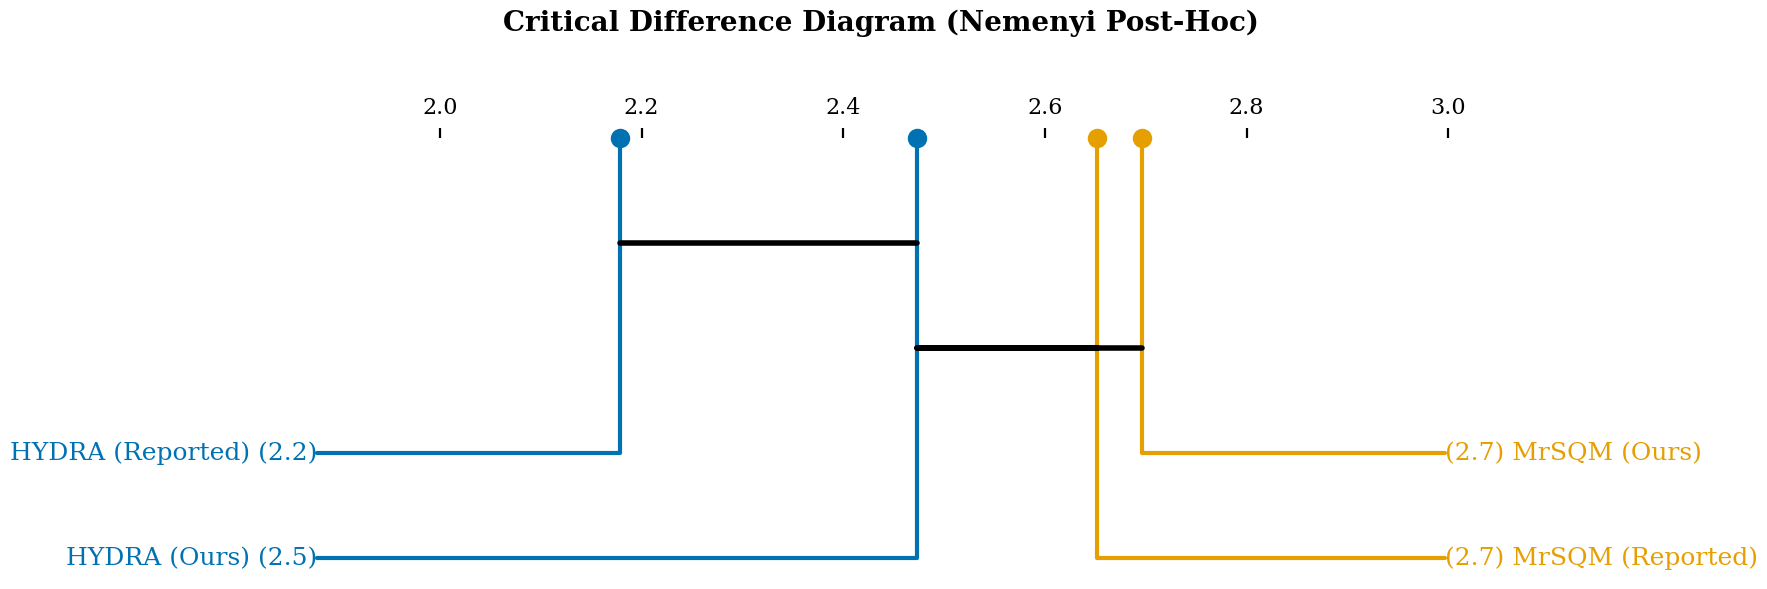

[plot_critical_difference] Saved -> figures/critical_difference.png


'figures/critical_difference.png'

In [40]:
_plot_critical_difference(df)